In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import os
import sklearn
import umap.umap_ as umap

# что сделать 12.05

Бинирование по углу и энергии и посмотреть что происходит 

KDE cовместно с recos

Заменить декодер с трансформера на FC где rec = F(lat, x_detector)

Передать деокеру recos для востановления 

сравнить реконструкцию неронной сети с реконтрукцией Рубцова (должно быть не хуже)


Предсказывать не данные а поправку рубцова к этим данным

In [2]:
import h5py
h5_path = '/home3/rfit/Telescope_Array/phd_work/data/normed/Ivan_Kharuk_pr_ga_all_0001_eq_eff_normed_one_work.h5'
with h5py.File(h5_path, 'r') as f:
    print(f.keys())
    print(f['norm_param'].keys())
    print(f['norm_param']['recos'].keys())
    mean_recos = f['norm_param']['recos']['mean'][:]
    std_recos = f['norm_param']['recos']['std'][:]
    print(mean_recos.shape, std_recos.shape)
    

<KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
<KeysViewHDF5 ['dt_bundle', 'dt_params', 'recos', 'wfs_flat']>
<KeysViewHDF5 ['mean', 'std']>
(15,) (15,)


In [4]:
path_save = '/home/rfit/Telescope_Array/phd_work/src/train_VAE/runs_tests_Kharuk_one_work'
path_save = '/home/rfit/Telescope_Array/phd_work/src/train_VAE/info_Transfoemr_Kharuk_one_work_photon_0.01'


In [5]:
os.listdir(path_save)

['photon', 'pr']

In [6]:
os.listdir(os.path.join(path_save, 'pr'))

['recos.npy',
 'preds_num_det.npy',
 'num_det.npy',
 'recon_loss.npy',
 'embading.npy',
 'preds_log_var.npy',
 'loss_num_det.npy']

In [7]:
num_det_pr = np.load(os.path.join(path_save, 'pr', 'num_det.npy'))
num_det_photon = np.load(os.path.join(path_save, 'photon', 'num_det.npy'))
num_det_pr.shape, num_det_photon.shape, num_det_pr[:20]

((210315,),
 (210851,),
 array([ 8.,  9., 15.,  9., 13., 10.,  7.,  7.,  9., 11., 12., 19., 10.,
        13., 12.,  7., 12., 12.,  8., 17.]))

In [8]:
recon_loss_pr = np.load(os.path.join(path_save, 'pr', 'recon_loss.npy'))
recon_loss_photon = np.load(os.path.join(path_save, 'photon', 'recon_loss.npy'))
recon_loss_pr.shape, recon_loss_photon.shape, recon_loss_pr[:20]

((210315,),
 (210851,),
 array([0.001827  , 0.00247437, 0.00407066, 0.00255517, 0.002139  ,
        0.00406251, 0.00820219, 0.0091447 , 0.00102208, 0.00811558,
        0.00993743, 0.0059569 , 0.00330811, 0.00822574, 0.01087788,
        0.00270496, 0.00997748, 0.00473928, 0.00195385, 0.00502905]))

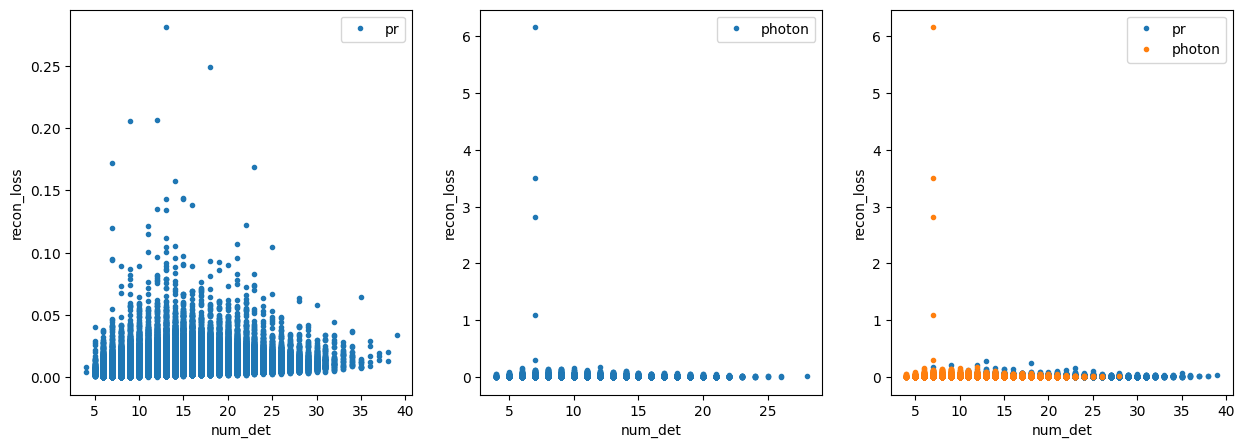

In [14]:
fig, ax = plt.subplots(1,3, figsize=(15, 5))
ax[0].plot(num_det_pr, recon_loss_pr, '.', label='pr')
ax[0].legend()
ax[1].plot(num_det_photon, recon_loss_photon, '.', label='photon')
ax[1].legend()
ax[2].plot(num_det_pr, recon_loss_pr, '.', label='pr')
ax[2].plot(num_det_photon, recon_loss_photon, '.', label='photon')
ax[2].legend()
for i in range(3):
    ax[i].set_xlabel('num_det')
    ax[i].set_ylabel('recon_loss')
plt.show()

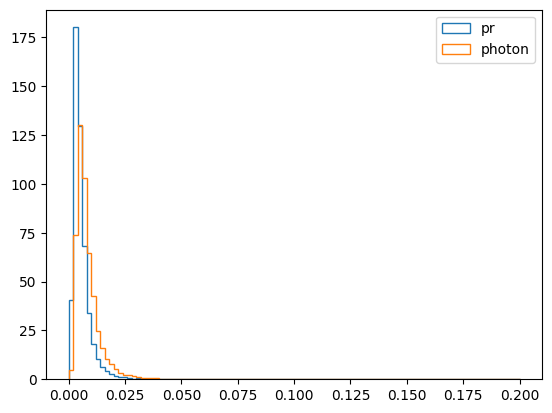

In [15]:
num=10
range_hist = (0,0.2)
plt.hist(recon_loss_pr[num_det_pr == num], density=True, bins=100, label='pr', histtype='step', range=range_hist)
plt.hist(recon_loss_photon[num_det_photon == num], density=True, bins=100, label='photon', histtype='step', range=range_hist)
plt.legend()
plt.show()

In [19]:
embading_pr = np.load(os.path.join(path_save, 'pr', 'embading.npy'))
embading_photon = np.load(os.path.join(path_save, 'photon', 'embading.npy'))
recos_pr = np.load(os.path.join(path_save, 'pr', 'recos.npy'))
recos_photon = np.load(os.path.join(path_save, 'photon', 'recos.npy'))

recos_norming_pr = recos_pr * std_recos + mean_recos
recos_norming_photon = recos_photon * std_recos + mean_recos

embading_pr.shape, embading_photon.shape, recos_pr.shape,




((210315, 8), (210851, 8), (210315, 15))


    recos (num_evs,15):
    0. theta
    1. phi
    2. S_800
    3. E_gamma
    4. d_border, km
    5. chi2/ndof for joint fit
    6. Linsley front curvature
    7. Area-over-peak (AOP) 1200
    8. AOP slope
    9. S_b parameter, b=2.5 (arXiv:1104.3399, arXiv:1305.7439)
    10. S_b parameter, b=4.0
    11. sum of all signals in all detectors
    12. asymmetry  of  the  summed signal  at  the  upper  and  lower layers of detectors
    13. total number of peaks in event
    14. number of peaks for the detector with the largest signal

In [ ]:
# В изначально ненормированных данных val*10^18

# После нормировки 
# 0- это 0
# 1.0 энергия 10^18
# 10.0 энергия 10^19

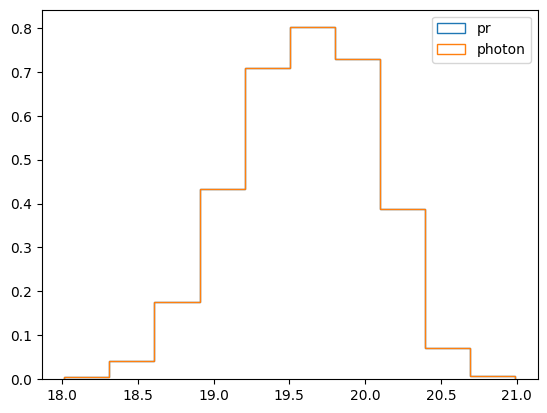

In [24]:
plt.hist(np.log10(recos_norming_pr[:,3])+18 ,histtype='step',density=True, label='pr',)
plt.hist(np.log10(recos_norming_photon[:,3])+18,histtype='step',density=True, label='photon',)
plt.legend()

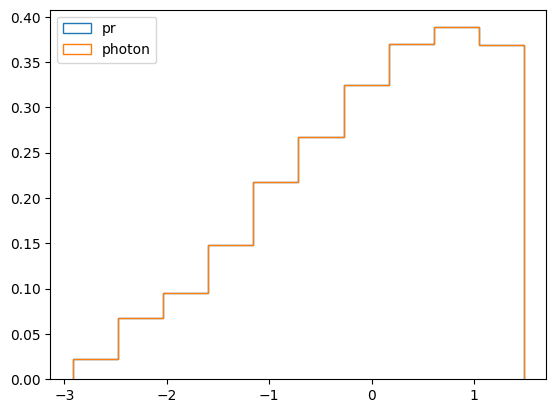

In [25]:
plt.hist(recos_pr[:,0],histtype='step',density=True, label='pr')
plt.hist(recos_photon[:,0],histtype='step',density=True, label='photon')
plt.legend()

In [ ]:
# Разбивка по бинам с равным количеством событий

In [ ]:
indices_pr_E = np.argsort(recos_norming_pr[:,3])
indices_photon_E = np.argsort(recos_norming_photon[:,3])
num_bins = 20

indices_pr_E = 


In [41]:
num_det_pr.shape,idex_pr.shape

((210315,), (47266,))

In [40]:
min_E = 0
max_E = 1
min_th = 0
max_th = 0.1

idex_pr = (recos_pr[:,3] > min_E) * (recos_pr[:,3] < max_E)
idex_photon = (recos_photon[:,3] > min_E) * (recos_photon[:,3] < max_E)
embading_pr = embading_pr[idex_pr]
embading_photon = embading_photon[idex_photon]
recos_pr = recos_pr[idex_pr]
recos_photon = recos_photon[idex_photon]


num_det_pr = num_det_pr[idex_pr]
num_det_photon = num_det_photon[idex_photon]
embading_pr.shape,num_det_pr.shape, embading_photon.shape, recos_pr.shape,

IndexError: boolean index did not match indexed array along dimension 0; dimension is 210315 but corresponding boolean dimension is 47266

In [24]:
def get_metrics(score_samples, score_samples_photon, th):
    FP_index = np.where(score_samples < th)[0]
    TP_index = np.where(score_samples_photon < th)[0]
    FN_index = np.where(score_samples_photon > th)[0]
    TN_index = np.where(score_samples > th)[0]
    part_anomalys_pr = len(FP_index)/len(score_samples)
    part_anomalys_ph = len(TP_index)/len(score_samples_photon)
    recall = len(TP_index) / (len(TP_index) + len(FN_index)+1e-10)
    precision = len(TP_index) / (len(TP_index) + len(FP_index)+1e-10)
    f1 = 2 * precision * recall / (precision + recall+1e-10)
    return recall, precision, f1, part_anomalys_pr, part_anomalys_ph

In [25]:
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KernelDensity
def full_test_prob(feaches_pr, feaches_photon,feaches_pr_test = None,n_components=1, range_hist=(-20, 0)):
    fig, axs = plt.subplots(3, 1, figsize=(7, 15))
    # clf = mixture.GaussianMixture(n_components=n_components, covariance_type="full")
    clf = KernelDensity(kernel='gaussian', bandwidth=0.1)
    clf.fit(feaches_pr)
    if feaches_pr_test is None:
        score_samples = clf.score_samples(feaches_pr)
        score_samples_photon = clf.score_samples(feaches_photon)
    else:
        score_samples = clf.score_samples(feaches_pr_test)
        score_samples_photon = clf.score_samples(feaches_photon)
    print(score_samples)
    print(score_samples_photon)
    axs[0].hist(score_samples, bins=100, label='pr', histtype='step', density=True, range=range_hist)
    axs[0].hist(score_samples_photon, bins=100, label='ph', histtype='step', density=True, range=range_hist)
    axs[0].legend()
    axs[0].set_title('hist')
    axs[0].grid()

    recall_list = []    
    precision_list = []
    f1_list = []
    part_anomalys_pr_list = []
    part_anomalys_ph_list = []
    min_score = min(score_samples.min(), score_samples_photon.min())
    max_score = max(score_samples.max(), score_samples_photon.max())
    for th in np.linspace(min_score, max_score, 100):
        recall, precision, f1, part_anomalys_pr, part_anomalys_ph = get_metrics(score_samples, score_samples_photon, th)
        recall_list.append(recall)
        precision_list.append(precision)
        f1_list.append(f1)
        part_anomalys_pr_list.append(part_anomalys_pr)
        part_anomalys_ph_list.append(part_anomalys_ph)
    axs[1].plot(np.linspace(-20, 2, 100), recall_list, label='recall')
    axs[1].plot(np.linspace(-20, 2, 100), precision_list, label='precision')
    axs[1].plot(np.linspace(-20, 2, 100), f1_list, label='f1')
    axs[1].plot(np.linspace(-20, 2, 100), part_anomalys_pr_list, label='part_anomalys_pr')
    axs[1].plot(np.linspace(-20, 2, 100), part_anomalys_ph_list, label='part_anomalys_ph')
    axs[1].legend()
    axs[1].set_title('metrics')
    axs[1].grid()

    #roc curve
    label_pr = np.zeros_like(score_samples)
    label_ph = np.ones_like(score_samples_photon)
    label = np.concatenate((label_pr, label_ph))
    loss = np.concatenate((-score_samples, -score_samples_photon))
    fpr, tpr, thresholds = roc_curve(label, loss)
    auc_ = auc(fpr, tpr)
    axs[2].plot(fpr, tpr)
    axs[2].text(0.5, 0.5, f'auc: {auc_:.2f}', fontsize=12, ha='center', va='center')
    axs[2].set_title(f'roc curve')
    axs[2].grid()
    print(thresholds.min(), thresholds.max())
    plt.show()

    
    

In [26]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.ensemble import IsolationForest

num =47000
num_ph = 400
print(f'part of data {num_ph/num}')
test_num = 10000
print('pr', embading_pr.shape, 'ph', embading_photon.shape)
index = np.random.randint(0, len(embading_pr), num)
index_ph = np.random.randint(0, len(embading_photon), num_ph)
feaches_pr = np.concatenate([embading_pr[index], num_det_pr[index].reshape(-1,1), recon_loss_pr[index].reshape(-1,1), recos_pr[index]], axis=1)

feaches_photon = np.concatenate([embading_photon[index_ph], num_det_photon[index_ph].reshape(-1,1), recon_loss_photon[index_ph].reshape(-1,1), recos_photon[index_ph]], axis=1)

feaches = np.concatenate([feaches_pr, feaches_photon], axis=0)
# label_pr = np.zeros(num)
# label_ph = np.ones(num_ph)
# label = np.concatenate((label_pr, label_ph))
# feaches_pr_test = np.concatenate([embading_pr[-test_num:], num_det_pr[-test_num:].reshape(-1,1), recon_loss_pr[-test_num:].reshape(-1,1)], axis=1)

# feaches_photon_test = np.concatenate([embading_photon[-test_num:], num_det_photon[-test_num:].reshape(-1,1), recon_loss_photon[-test_num:].reshape(-1,1)], axis=1)
# feaches: твой массив shape [N, D]
X = feaches.copy()
print(X.shape)
# Лучше RobustScaler, чем StandardScaler, для задач с выбросами
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

part of data 0.00851063829787234
pr (47266, 8) ph (47384, 8)
(47400, 25)


In [27]:
def show_2d(pr, ph, use_ph=True):
    # pr_index= np.random.randint(0, pr.shape[0], size=5000)
    # ph_index= np.random.randint(0, ph.shape[0], size=5000)
    # pr = pr[pr_index]
    # ph = ph[ph_index]
    reducer = umap.UMAP(n_components=2)
    if use_ph:
        manifold = reducer.fit(np.concatenate([pr, ph], axis=0))
    else:
        manifold = reducer.fit(pr)
    X_pr = manifold.transform(pr)
    X_ph = manifold.transform(ph)


    fig, ax = plt.subplots(2,3, figsize=(12, 12))
    ax_1, ax_2, ax_3 = ax[0]
    ax_1.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_2.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_3.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_3.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_1.legend()
    ax_2.legend()
    ax_3.legend()

    tsne = sklearn.manifold.TSNE(n_components=2)
    if use_ph:
        X_tsne = tsne.fit_transform(np.concatenate([pr, ph], axis=0))
        X_tsne_pr = X_tsne[:pr.shape[0]]
        X_tsne_ph = X_tsne[pr.shape[0]:]
    else:
        X_tsne = tsne.fit_transform(pr)
        X_tsne_pr = X_tsne

    ax_1, ax_2, ax_3 = ax[1]
    ax_1.scatter(X_tsne_pr[:, 0], X_tsne_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_2.scatter(X_tsne_ph[:, 0], X_tsne_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_3.scatter(X_tsne_pr[:, 0], X_tsne_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_3.scatter(X_tsne_ph[:, 0], X_tsne_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_1.legend()
    ax_2.legend()
    ax_3.legend()
    plt.show()

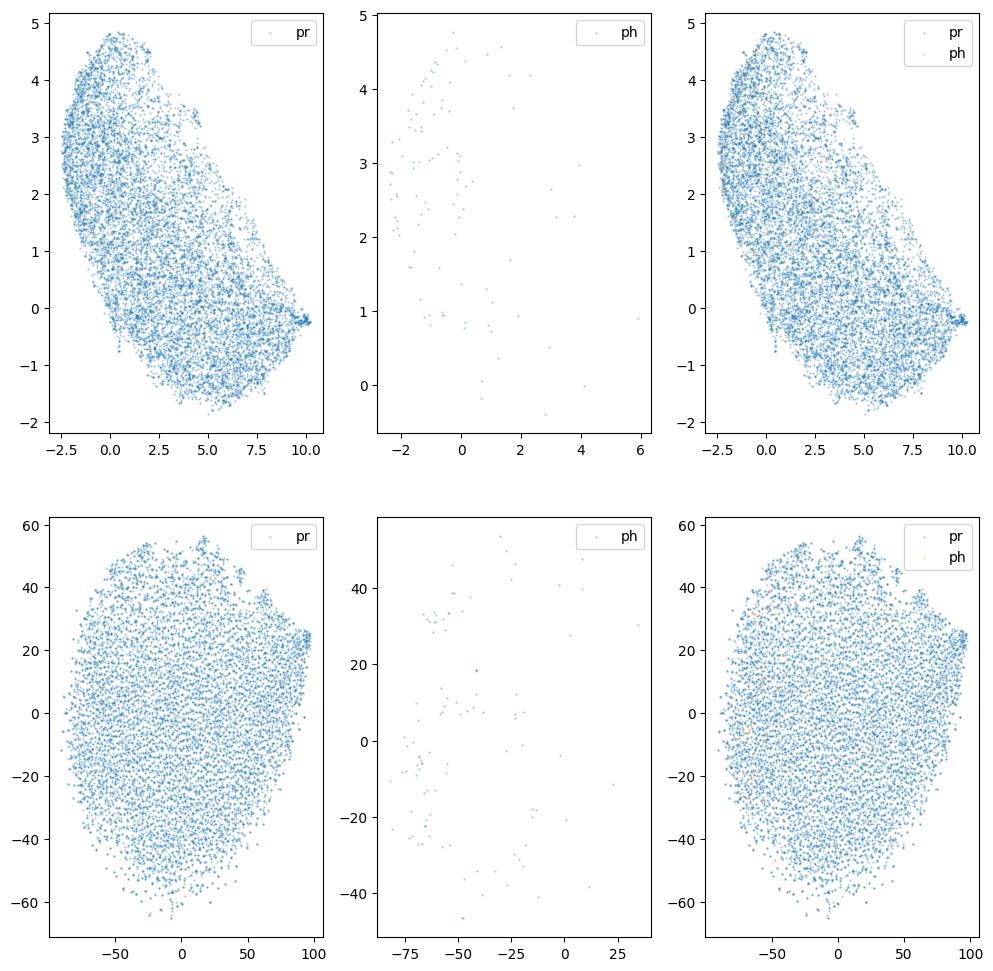

In [28]:
pr = feaches_pr
ph = feaches_photon
show_2d(pr[:10000], ph[:100])

In [29]:
from scipy.stats import gaussian_kde
def show_2d_density(pr, ph, use_ph=True, n_ph=1, density_ph = None, density_pr = None):
    # pr_index= np.random.randint(0, pr.shape[0], size=5000)
    # ph_index= np.random.randint(0, ph.shape[0], size=5000)
    # pr = pr[pr_index]
    # ph = ph[ph_index]
    reducer = umap.UMAP(n_components=2)
    if use_ph:
        manifold = reducer.fit(np.concatenate([pr, ph[::n_ph]], axis=0))
    else:
        manifold = reducer.fit(pr)
    X_pr = manifold.transform(pr)
    X_ph = manifold.transform(ph)

    fig, ax = plt.subplots(2,3, figsize=(12, 12))
    ax_1, ax_2, ax_3 = ax[0]
    ax_1.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_2.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_3.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_3.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_1.legend()
    ax_2.legend()
    ax_3.legend()

    X_all = np.vstack([X_pr, X_ph[::n_ph]])
    kde = gaussian_kde(X_all.T, )
    density = kde(X_all.T)  # shape: (N,)


    x_min, x_max = X_all[:, 0].min() - 1, X_all[:, 0].max() + 1
    y_min, y_max = X_all[:, 1].min() - 1, X_all[:, 1].max() + 1
    grid_x, grid_y = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
    density = kde(np.vstack([grid_x.ravel(), grid_y.ravel()]))
    density = density.reshape(grid_x.shape)

    ax_1, ax_2, ax_3 = ax[1]
    # Отображение плотности
    cmap = plt.colormaps['PiYG']
    # (1,0) - плотность для всех точек
    im = ax[1, 0].pcolormesh(grid_x, grid_y, density, cmap=cmap)
    ax[1, 0].set_title('Density (all)')
    fig.colorbar(im, ax=ax[1, 0], label='Density')
    
    ax[1,0].scatter(X_ph[:, 0], X_ph[:, 1],s=1, label='ph')
    # (1,1) и (1,2) можно оставить пустыми или повторить для pr и ph отдельно
    if density_ph is None:
        density_ph = kde(X_ph.T)
    if density_pr is None:
        density_pr = kde(X_pr.T)
    
    im = ax[1, 2].scatter(X_ph[:, 0], X_ph[:, 1], s=1, label='ph', c=density_ph, cmap='viridis')
    ax[1, 2].set_title('Density (ph)')
    fig.colorbar(im, ax=ax[1, 2], label='Density')
    
    ax[1,1].hist(density_ph, bins=100, label='ph', histtype='step', density=True, log=True)
    ax[1,1].hist(density_pr, bins=100, label='pr', histtype='step', density=True, log=True)
    ax[1,1].legend()
    ax[1,1].set_title('Density (ph and pr)')
    ax[1,1].grid()

    plt.tight_layout()
    plt.show()

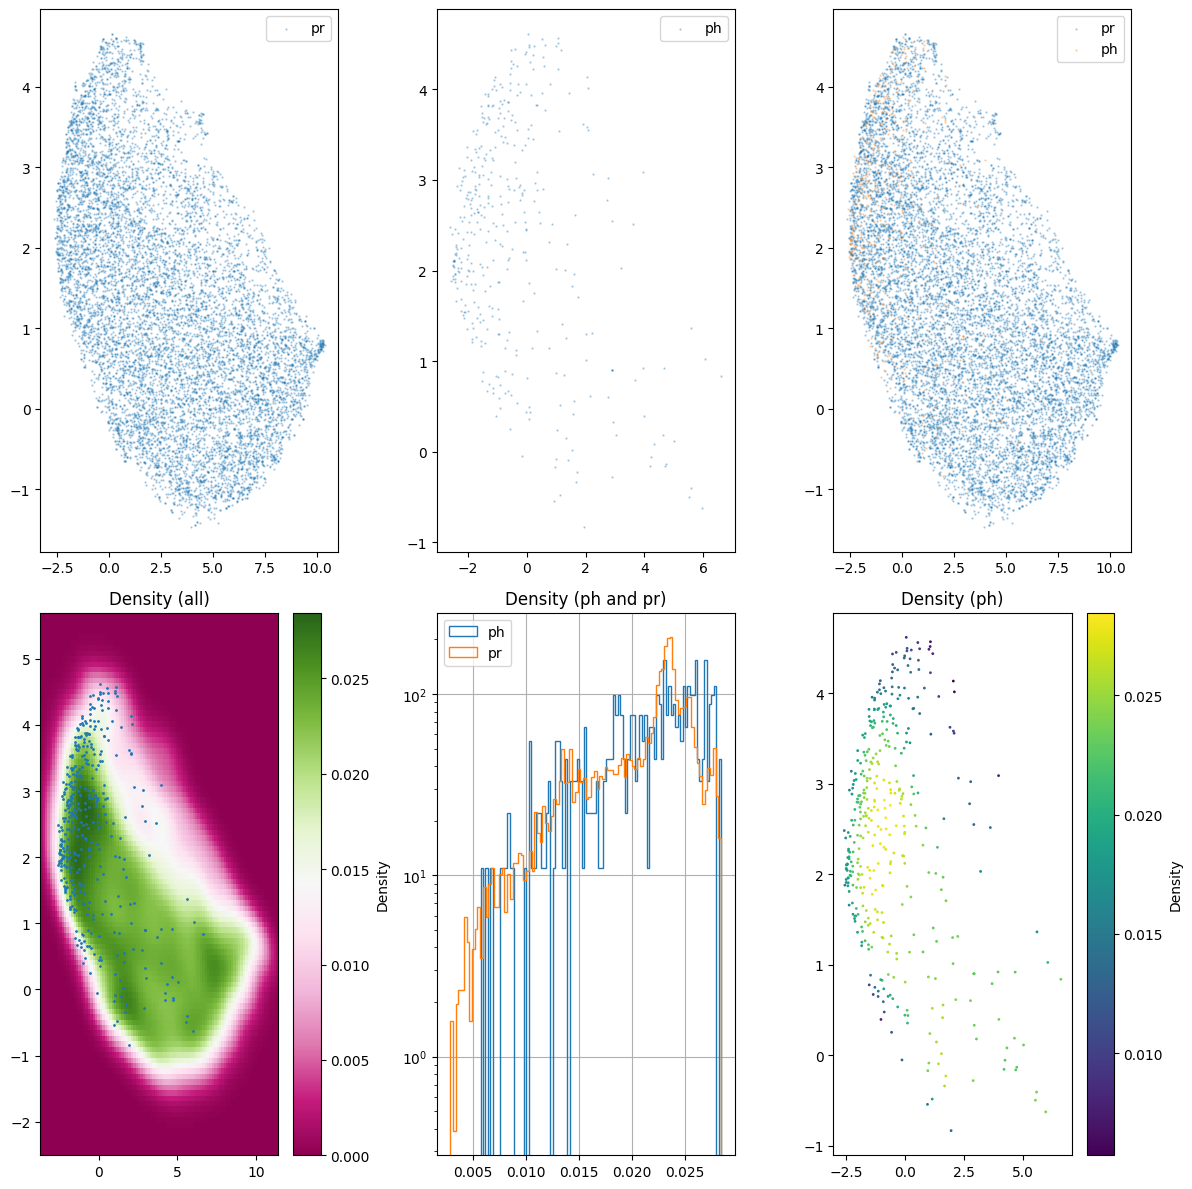

In [30]:
show_2d_density(pr[:10000],ph[:1000], n_ph=10)

In [31]:
def get_metrics(score_samples, score_samples_photon, th):
    FP_index = np.where(score_samples > th)[0]
    TP_index = np.where(score_samples_photon > th)[0]
    FN_index = np.where(score_samples_photon > th)[0]
    TN_index = np.where(score_samples < th)[0]
    part_anomalys_pr = len(FP_index)/len(score_samples)
    part_anomalys_ph = len(TP_index)/len(score_samples_photon)
    recall = len(TP_index) / (len(TP_index) + len(FN_index)+1e-10)
    precision = len(TP_index) / (len(TP_index) + len(FP_index)+1e-10)
    f1 = 2 * precision * recall / (precision + recall+1e-10)
    return recall, precision, f1, part_anomalys_pr, part_anomalys_ph
def get_top_anomalies(scores, top_percent=1.0):
    """
    Возвращает индексы top_percent самых аномальных точек.
    Чем больше score, тем более аномальна точка.
    """
    n_top = max(1, int(len(scores) * top_percent / 100.0))
    idx_sorted = np.argsort(scores)[::-1]   # по убыванию anomaly score
    top_idx = idx_sorted[:n_top]
    return top_idx, scores[top_idx]

def make_result_df(scores, name="score"):
    df = pd.DataFrame({
        "index": np.arange(len(scores)),
        name: scores
    })
    df = df.sort_values(name, ascending=False).reset_index(drop=True)
    return df

In [32]:
def iforest_anomaly_score(X_scaled, n_estimators=300, max_samples="auto", random_state=42):
    """
    Isolation Forest.
    Чем больше score, тем более аномальна точка.
    """
    clf = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        contamination=0.025,
        random_state=random_state,
        n_jobs=-1
    )

    clf.fit(X_scaled)

    # score_samples: больше = более нормальная точка
    # берем минус, чтобы больше = более аномальная
    scores = -clf.score_samples(X_scaled)

    return scores

iforest_scores = iforest_anomaly_score(X_scaled[:,:8], n_estimators=100, random_state=42)
df_iforest = make_result_df(iforest_scores, name="iforest_score")


    index  iforest_score particle
0   47175       0.643470       ph
1   19595       0.631953       pr
2   35856       0.631953       pr
3   12810       0.627944       pr
4   10736       0.627944       pr
5   40838       0.627417       pr
6   19029       0.627417       pr
7   28529       0.627417       pr
8   16981       0.625570       pr
9   36688       0.624813       pr
10  40047       0.618400       pr
11   4811       0.618400       pr
12  34080       0.618331       pr
13   3967       0.618331       pr
14  29941       0.617695       pr
15  12747       0.617695       pr
16  31929       0.617118       pr
17  41770       0.611483       pr
18  29378       0.604844       pr
19   3317       0.604832       pr
       index  iforest_score particle
47380  45942       0.370805       pr
47381  33854       0.370722       pr
47382    471       0.370457       pr
47383  15260       0.370457       pr
47384   3461       0.370457       pr
47385  34943       0.370212       pr
47386  19675       0.370212

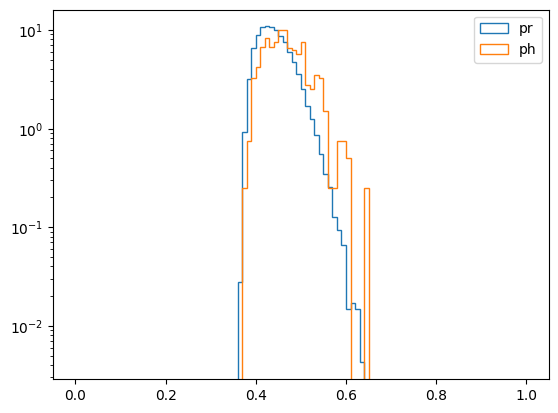

In [33]:
df_iforest['particle'] = np.where(df_iforest['index'] < num, 'pr', 'ph')
print(df_iforest.head(20))
print(df_iforest.tail(20))
print(len(df_iforest[df_iforest['particle'] == 'pr']))
print(len(df_iforest[df_iforest['particle'] == 'ph']))
print(len(df_iforest))
plt.hist(df_iforest[df_iforest['particle'] == 'pr']['iforest_score'], bins=100, label='pr', log=True, density=True, histtype='step', range=(0, 1))
plt.hist(df_iforest[df_iforest['particle'] == 'ph']['iforest_score'], bins=100, label='ph', log=True, density=True, histtype='step', range=(0, 1))
plt.legend()
plt.show()

(47000,) (400,)


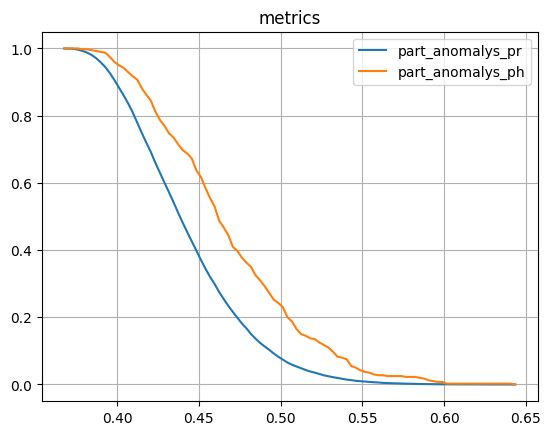

In [34]:
value = np.array(df_iforest['iforest_score'])
label_df = np.where(df_iforest['particle'] == 'pr', 0, 1)
score_samples = value[label_df == 0]
score_samples_photon = value[label_df == 1]
print(score_samples.shape, score_samples_photon.shape)
recall_list = []    
precision_list = []
f1_list = []
part_anomalys_pr_list = []
part_anomalys_ph_list = []
min_score = min(score_samples.min(), score_samples_photon.min())
max_score = max(score_samples.max(), score_samples_photon.max())
for th in np.linspace(min_score, max_score, 100):
    recall, precision, f1, part_anomalys_pr, part_anomalys_ph = get_metrics(score_samples, score_samples_photon, th)
    recall_list.append(recall)
    precision_list.append(precision)
    f1_list.append(f1)
    part_anomalys_pr_list.append(part_anomalys_pr)
    part_anomalys_ph_list.append(part_anomalys_ph)
# plt.plot(np.linspace(min_score, max_score, 100), recall_list, label='recall')
# plt.plot(np.linspace(min_score, max_score, 100), precision_list, label='precision')
# plt.plot(np.linspace(min_score, max_score, 100), f1_list, label='f1')
plt.plot(np.linspace(min_score, max_score, 100), part_anomalys_pr_list, label='part_anomalys_pr')
plt.plot(np.linspace(min_score, max_score, 100), part_anomalys_ph_list, label='part_anomalys_ph')
plt.legend()
plt.title('metrics')
plt.grid()

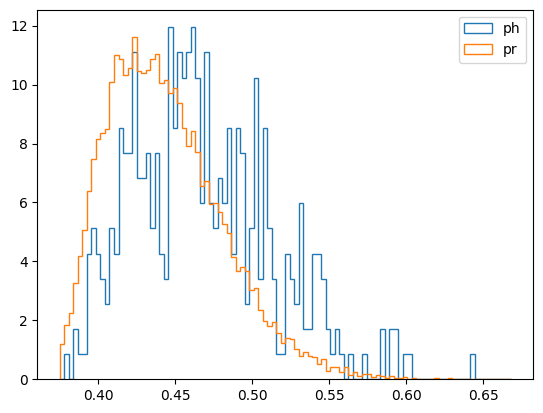

array([0.64347044, 0.63195274, 0.63195274, ..., 0.36797376, 0.36765801,
       0.36765801])

In [35]:
plt.hist(score_samples_photon, bins=100, label='ph', histtype='step', density=True, range=(0.375, 0.668))
plt.hist(score_samples, bins=100, label='pr', histtype='step', density=True, range=(0.375, 0.668))
plt.legend()
plt.show()
value


(array([ 0.        ,  0.85324232,  0.        ,  1.70648464,  0.85324232,
         0.85324232,  4.2662116 ,  5.11945392,  4.2662116 ,  3.41296928,
         2.55972696,  5.11945392,  4.2662116 ,  8.53242321,  7.67918089,
         7.67918089, 11.09215017,  6.82593857,  6.82593857,  7.67918089,
         5.11945392,  7.67918089,  4.2662116 ,  3.41296928, 11.94539249,
         8.53242321, 11.09215017, 10.23890785, 11.09215017, 11.94539249,
        10.23890785,  5.97269625, 11.09215017,  5.97269625,  5.11945392,
         6.82593857,  5.97269625,  8.53242321,  4.2662116 ,  8.53242321,
         7.67918089,  2.55972696,  5.11945392, 10.23890785,  3.41296928,
         8.53242321,  5.11945392,  3.41296928,  0.85324232,  0.85324232,
         4.2662116 ,  3.41296928,  2.55972696,  5.97269625,  1.70648464,
         1.70648464,  4.2662116 ,  4.2662116 ,  3.41296928,  1.70648464,
         0.85324232,  1.70648464,  0.85324232,  0.        ,  0.85324232,
         0.        ,  0.        ,  0.85324232,  0. 

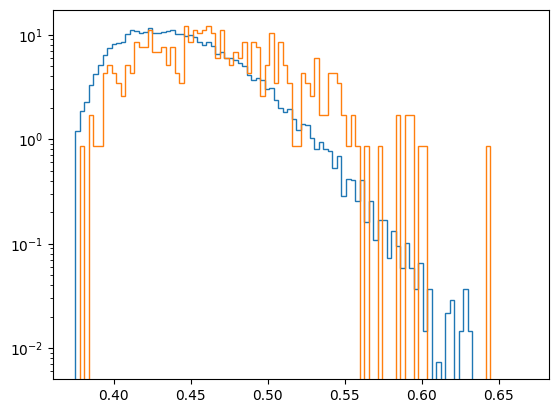

In [36]:
plt.hist(df_iforest[df_iforest['particle'] == 'pr']['iforest_score'], bins=100, label='pr', log=True, density=True, histtype='step', range=(0.375, 0.668))
plt.hist(df_iforest[df_iforest['particle'] == 'ph']['iforest_score'], bins=100, label='ph', log=True, density=True, histtype='step', range=(0.375, 0.668))


In [37]:
# KDE

In [38]:
from sklearn.neighbors import KernelDensity

In [ ]:
num =47000
num_ph = 400
print(f'part of data {num_ph/num}')
print('pr', embading_pr.shape, 'ph', embading_photon.shape)
index = np.random.randint(0, len(embading_pr), num)
index_ph = np.random.randint(0, len(embading_photon), num_ph)
# with recos

# feaches_pr = np.concatenate([embading_pr[index], num_det_pr[index].reshape(-1,1), recon_loss_pr[index].reshape(-1,1), recos_pr[index]], axis=1)

# feaches_photon = np.concatenate([embading_photon[index_ph], num_det_photon[index_ph].reshape(-1,1), recon_loss_photon[index_ph].reshape(-1,1), recos_photon[index_ph]], axis=1)

# without recos
feaches_pr = np.concatenate([embading_pr[index], num_det_pr[index].reshape(-1,1), recon_loss_pr[index].reshape(-1,1)], axis=1)

feaches_photon = np.concatenate([embading_photon[index_ph], num_det_photon[index_ph].reshape(-1,1), recon_loss_photon[index_ph].reshape(-1,1)], axis=1)

feaches = np.concatenate([feaches_pr, feaches_photon], axis=0)

label = np.concatenate([np.zeros(num), np.ones(num_ph)])

# shufle
shufle_index = np.random.permutation(len(feaches))
feaches = feaches[shufle_index]
label = label[shufle_index]

num_det_feaches = feaches[:,8]

print(feaches[:10], label[:10])

part of data 0.01
pr (210315, 8) ph (210851, 8)
[[ 2.71117657e-01 -3.02212179e-01  4.47371542e-01 -2.00935170e-01
  -2.22648948e-01  6.42906547e-01  1.37234735e+00 -3.85867864e-01
   1.50000000e+01  4.91588842e-03]
 [-5.61187565e-02  1.96466237e-01  6.38024867e-01 -3.48139942e-01
  -4.13642257e-01  9.86369729e-01 -1.55401349e-01 -1.42150104e+00
   1.00000000e+01  4.01986111e-03]
 [-1.44109440e+00 -3.22611064e-01  4.57825840e-01 -4.85165536e-01
  -8.37534785e-01 -3.56241435e-01 -5.54095745e-01 -5.97271621e-02
   8.00000000e+00  5.47316950e-03]
 [ 7.21854687e-01 -9.86058474e-01  1.83402014e+00  9.26690400e-01
   1.23438179e+00  1.62518954e+00  2.00069189e-01 -2.18126506e-01
   1.90000000e+01  4.79897158e-03]
 [-1.16458380e+00  4.93810803e-01 -6.08782709e-01  7.76405871e-01
   8.89455795e-01 -1.14525402e+00 -5.53275883e-01 -6.84901714e-01
   1.30000000e+01  5.03659155e-03]
 [-4.34778035e-01 -1.12477779e+00 -1.03038371e-01 -6.34431779e-01
  -2.63369918e-01  1.33158326e+00 -1.54675758e+00  

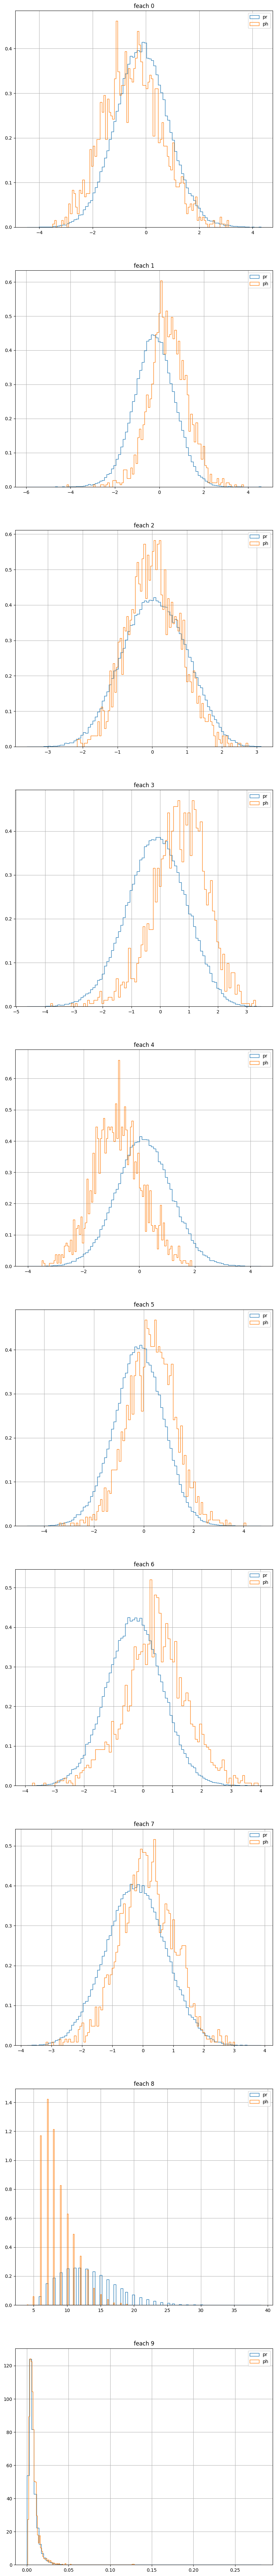

In [53]:
fig, ax = plt.subplots(feaches.shape[1],1, figsize=(10, feaches.shape[1]*10))
for i in range(feaches.shape[1]):
    ax[i].hist(feaches[label == 0,i], bins=100, label=f'pr', histtype='step', density=True)
    ax[i].hist(feaches[label == 1,i], bins=100, label=f'ph', histtype='step', density=True)
    ax[i].legend()
    ax[i].set_title(f'feach {i}')
    ax[i].grid()
plt.show()



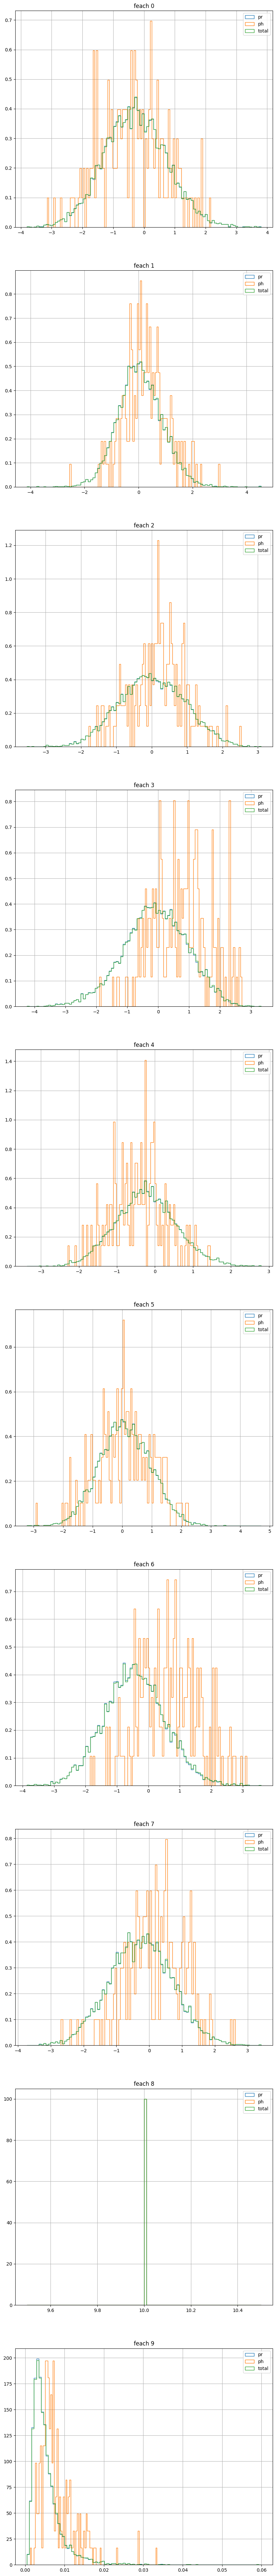

In [54]:
N=10
fig, ax = plt.subplots(feaches.shape[1],1, figsize=(10, feaches.shape[1]*10))
for i in range(feaches.shape[1]):
    ax[i].hist(feaches[label == 0,i][num_det_feaches[label == 0] == N], bins=100, label=f'pr', histtype='step', density=True)
    ax[i].hist(feaches[label == 1,i][num_det_feaches[label == 1] == N], bins=100, label=f'ph', histtype='step', density=True)
    ax[i].hist(feaches[:,i][num_det_feaches == N], bins=100, label=f'total', histtype='step', density=True)
    ax[i].legend()
    ax[i].set_title(f'feach {i}')
    ax[i].grid()
plt.show()

(4182, 10) (351, 10)


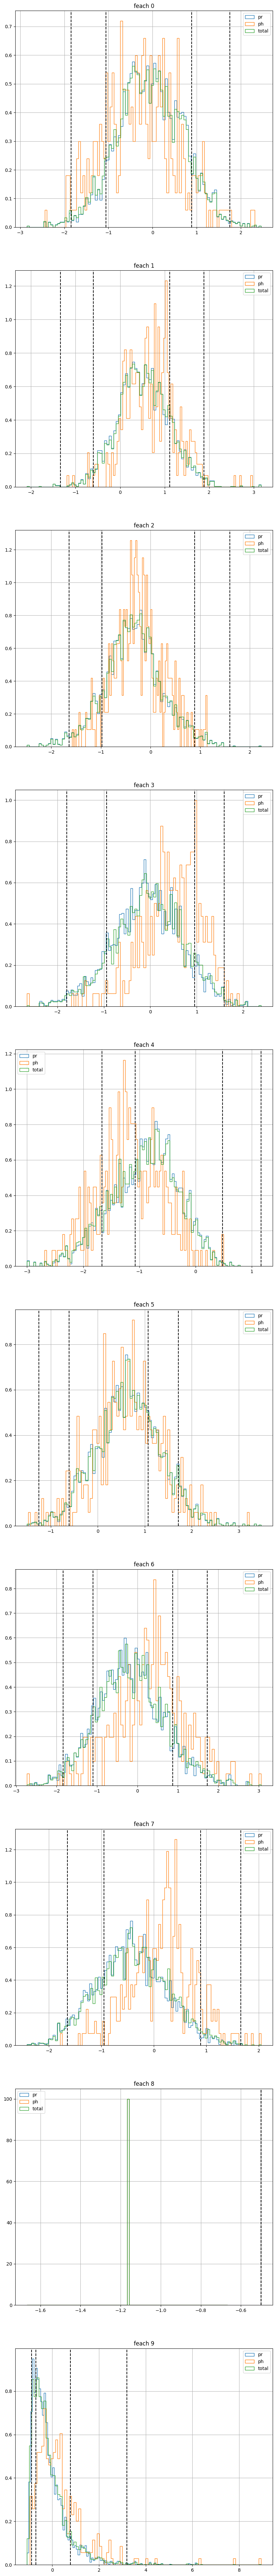

In [110]:
# quantile
quan_list = [0.01, 0.1, 0.9, 0.99]
quantile_feaches = np.quantile(feaches[num_det_feaches == N], quan_list, axis=0)
N=6
fig, ax = plt.subplots(feaches.shape[1],1, figsize=(10, feaches.shape[1]*10))
for i in range(feaches.shape[1]):
    ax[i].hist(feaches[label == 0,i][num_det_feaches[label == 0] == N], bins=100, label=f'pr', histtype='step', density=True)
    ax[i].hist(feaches[label == 1,i][num_det_feaches[label == 1] == N], bins=100, label=f'ph', histtype='step', density=True)
    ax[i].hist(feaches[:,i][num_det_feaches == N], bins=100, label=f'total', histtype='step', density=True)
    ax[i].legend()
    for j in range(quantile_feaches.shape[0]):
        ax[i].axvline(quantile_feaches[j,i], color='k', linestyle='--', label=f'quan {quan_list[j]}')
    ax[i].set_title(f'feach {i}')
    
    ax[i].grid()
pr = feaches[label == 0,:][num_det_feaches[label == 0] == N]
ph = feaches[label == 1,:][num_det_feaches[label == 1] == N]
print(pr.shape, ph.shape)


In [111]:
X = feaches[:][num_det_feaches == N].copy()
X = np.concatenate([X[:,:8], X[:,9:]], axis=1)
print(X.shape)
# Лучше RobustScaler, чем StandardScaler, для задач с выбросами
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled
label_X = label[num_det_feaches == N]
print('pr',(label_X == 0).sum(), 'ph', (label_X == 1).sum())
# feaches = X_scaled

(4533, 9)
pr 4182 ph 351


-8.678007253375608 -9.328885550802475
0.7696828590285193 0.5533935021023997


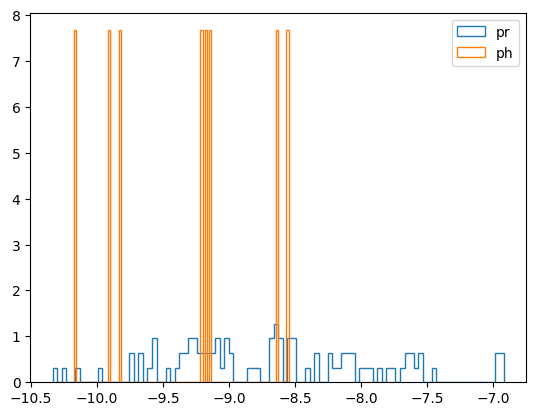

In [152]:
# kde

bandwidth = 0.5

num=100
index = np.random.randint(0, len(X_scaled), num)
kde = KernelDensity(bandwidth=bandwidth).fit(X_scaled)


scores = kde.score_samples(X_scaled[index])
label_scores = label_X[index]

plt.hist(scores[label_scores == 0], bins=100, label='pr', histtype='step', density=True,)
plt.hist(scores[label_scores == 1], bins=100, label='ph', histtype='step', density=True,)
print(scores[label_scores == 0].mean(), scores[label_scores == 1].mean())
print(scores[label_scores == 0].std(), scores[label_scores == 1].std())
plt.legend()
plt.show()




-8.696763985588163 -9.268409963581476
0.8679825944236718 0.9118806044780183


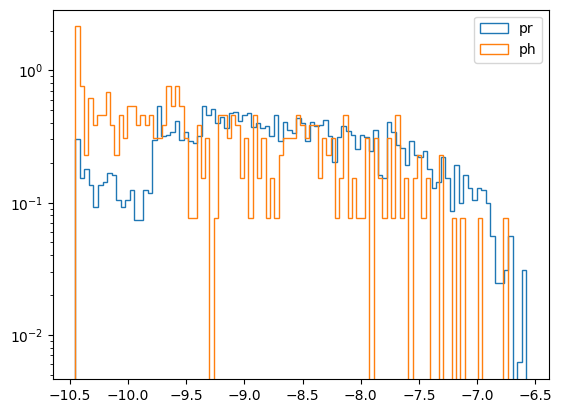

In [153]:
scores_pr = kde.score_samples(X_scaled[label_X == 0])
scores_ph = kde.score_samples(X_scaled[label_X == 1])
print(scores_pr.mean(), scores_ph.mean())
print(scores_pr.std(), scores_ph.std())
plt.hist(scores_pr, bins=100, label='pr', histtype='step', density=True, log=True)
plt.hist(scores_ph, bins=100, label='ph', histtype='step', density=True, log=True)
plt.legend()

-8.696763985588163 -9.268409963581476
0.8679825944236718 0.9118806044780183


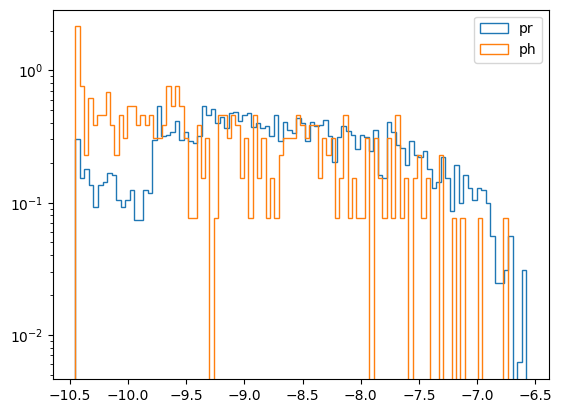

In [154]:
scores_pr = kde.score_samples(X_scaled[label_X == 0])
scores_ph = kde.score_samples(X_scaled[label_X == 1])
print(scores_pr.mean(), scores_ph.mean())
print(scores_pr.std(), scores_ph.std())
plt.hist(scores_pr, bins=100, label='pr', histtype='step', density=True, log=True)
plt.hist(scores_ph, bins=100, label='ph', histtype='step', density=True, log=True)
plt.legend()

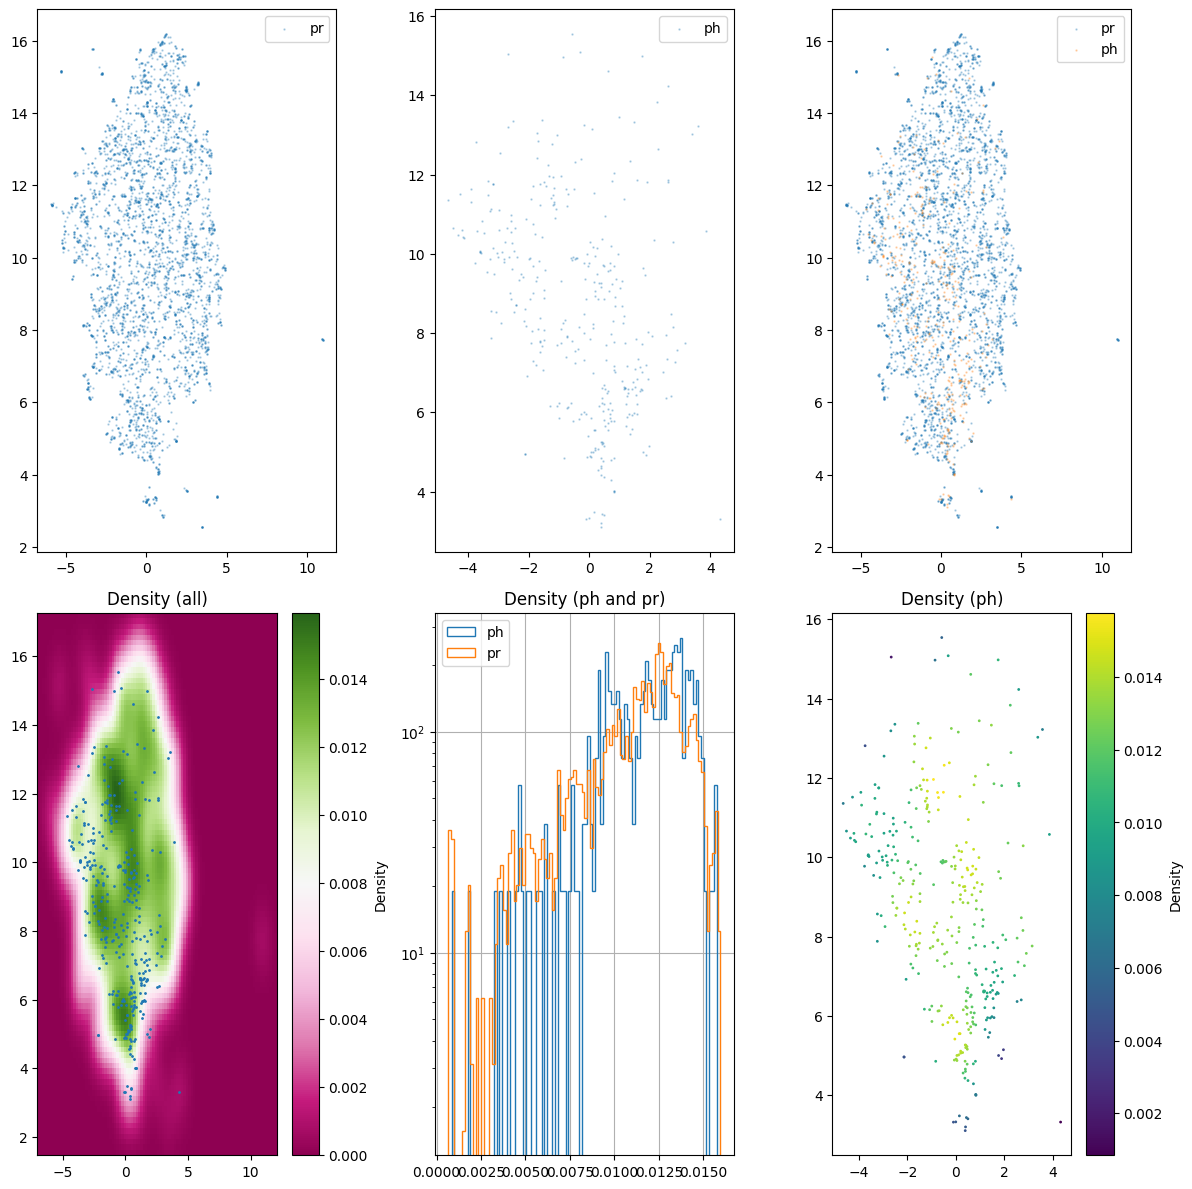

In [142]:
show_2d_density(X_scaled[label_X == 0], X_scaled[label_X == 1], n_ph=1)


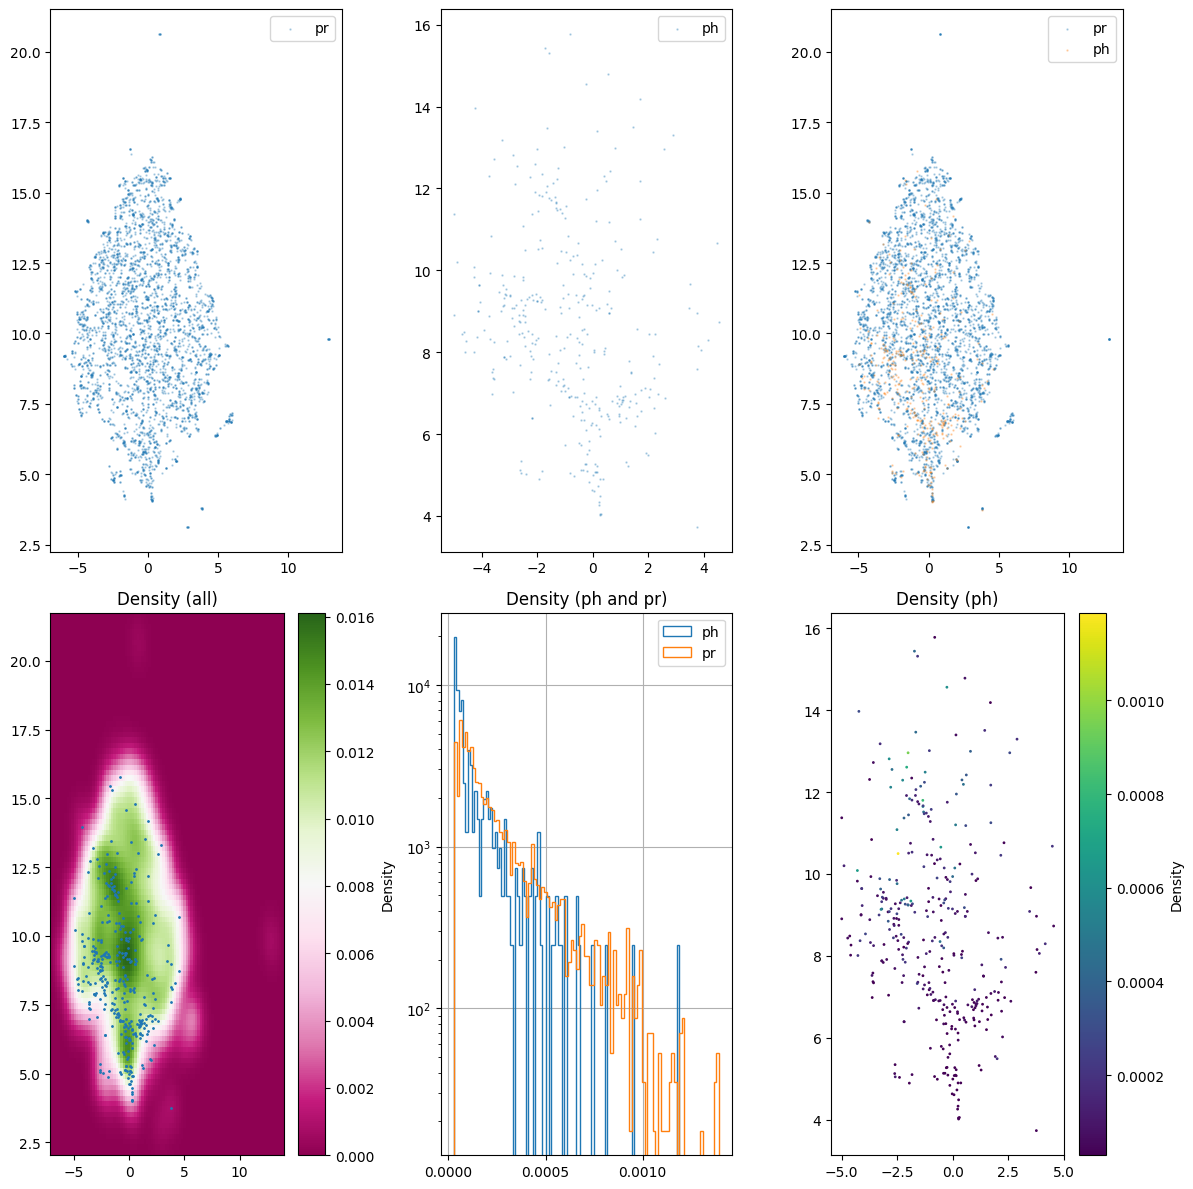

In [155]:
show_2d_density(X_scaled[label_X == 0], X_scaled[label_X == 1], n_ph=1, density_ph=np.exp(scores_ph), density_pr=np.exp(scores_pr))

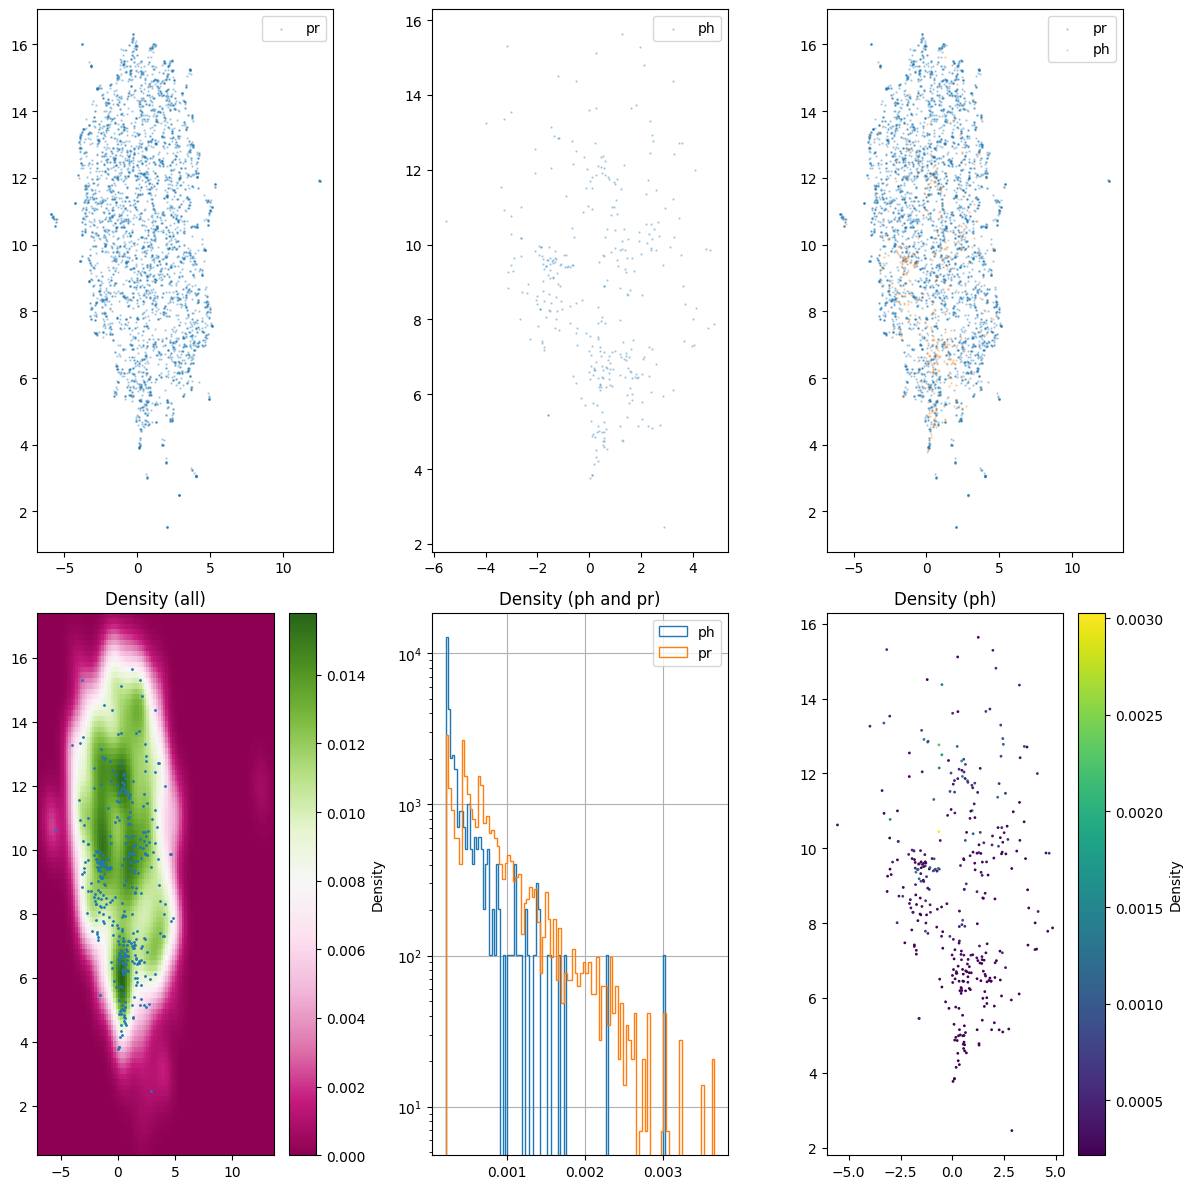

In [149]:
th = 0.011
pr_index = np.exp(scores_pr)<th
ph_index = np.exp(scores_ph)<th
show_2d_density(X_scaled[label_X == 0][pr_index], X_scaled[label_X == 1][ph_index], n_ph=1, density_ph=np.exp(scores_ph)[ph_index], density_pr=np.exp(scores_pr)[pr_index])

In [ ]:
quan_list = [0.01, 0.1, 0.9, 0.99]
quantile_feaches = np.quantile(feaches[num_det_feaches == N], quan_list, axis=0)
N=10
fig, ax = plt.subplots(feaches.shape[1],1, figsize=(10, feaches.shape[1]*10))
for i in range(feaches.shape[1]):
    ax[i].hist(feaches[label == 0,i][num_det_feaches[label == 0] == N], bins=100, label=f'pr', histtype='step', density=True)
    ax[i].hist(feaches[label == 1,i][num_det_feaches[label == 1] == N], bins=100, label=f'ph', histtype='step', density=True)
    ax[i].hist(feaches[:,i][num_det_feaches == N], bins=100, label=f'total', histtype='step', density=True)
    ax[i].legend()
    for j in range(quantile_feaches.shape[0]):
        ax[i].axvline(quantile_feaches[j,i], color='k', linestyle='--', label=f'quan {quan_list[j]}')
    ax[i].set_title(f'feach {i}')
    
    ax[i].grid()
pr = feaches[label == 0,:][num_det_feaches[label == 0] == N]
ph = feaches[label == 1,:][num_det_feaches[label == 1] == N]
print(pr.shape, ph.shape)


In [138]:
def show_del_by_score(pr, ph, use_ph=True, n_ph=1, density_ph = None, density_pr = None, th = 0.1):
    # pr_index= np.random.randint(0, pr.shape[0], size=5000)
    # ph_index= np.random.randint(0, ph.shape[0], size=5000)
    # pr = pr[pr_index]
    # ph = ph[ph_index]
    fig = plt.subplot()
    plt.hist(density_pr, bins=100, label='pr', histtype='step', density=True, log=True)
    plt.hist(density_ph, bins=100, label='ph', histtype='step', density=True, log=True)
    plt.axvline(th, color='k', linestyle='--', label=f'th')
    plt.legend()
    plt.show()
    fig, ax = plt.subplots(2,3, figsize=(12, 12))
    ax_1, ax_2, ax_3 = ax[0]
    reducer = umap.UMAP(n_components=2)
    if use_ph:
        manifold = reducer.fit(np.concatenate([pr, ph[::n_ph]], axis=0))
    else:
        manifold = reducer.fit(pr)
    X_pr = manifold.transform(pr)
    X_ph = manifold.transform(ph)

    X_all = np.vstack([X_pr, X_ph[::n_ph]])

    kde = gaussian_kde(X_all.T, )
    x_min, x_max = X_all[:, 0].min() - 1, X_all[:, 0].max() + 1
    y_min, y_max = X_all[:, 1].min() - 1, X_all[:, 1].max() + 1
    grid_x, grid_y = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
    density = kde(np.vstack([grid_x.ravel(), grid_y.ravel()]))
    density = density.reshape(grid_x.shape)
    cmap = plt.colormaps['PiYG']
    # (1,0) - плотность для всех точек
    im = ax[0, 2].pcolormesh(grid_x, grid_y, density, cmap=cmap)
    ax[0, 2].set_title('Density (all)')
    fig.colorbar(im, ax=ax[0, 2], label='Density')

    im = ax[1, 2].pcolormesh(grid_x, grid_y, density, cmap=cmap)
    ax[1, 2].set_title('Density (all)')
    fig.colorbar(im, ax=ax[1, 2], label='Density')

    ax_1, ax_2, ax_3 = ax[0]
    ax_1.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_2.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_3.scatter(X_pr[:, 0], X_pr[:, 1], s=0.5, alpha=0.3, label='pr')
    ax_3.scatter(X_ph[:, 0], X_ph[:, 1], s=0.5, alpha=0.3, label='ph')
    ax_1.legend()
    ax_2.legend()
    ax_3.legend()

    pr_index = density_pr<th
    ph_index = density_ph<th
    print(len(density_pr), len(density_ph))
    print(pr_index.sum(), ph_index.sum())
    print(len(X_pr[pr_index, 0]), len(X_ph[ph_index, 0]))
    ax_1, ax_2, ax_3 = ax[1]
    ax_1.scatter(X_pr[pr_index, 0], X_pr[pr_index, 1], s=0.5, alpha=0.3, label='pr')
    ax_2.scatter(X_ph[ph_index, 0], X_ph[ph_index, 1], s=0.5, alpha=0.3, label='ph')
    ax_3.scatter(X_pr[pr_index, 0], X_pr[pr_index, 1], s=0.5, alpha=0.3, label='pr')
    ax_3.scatter(X_ph[ph_index, 0], X_ph[ph_index, 1], s=0.5, alpha=0.3, label='ph')
    
    # ax[1,1].hist(density_ph, bins=100, label='ph', histtype='step', density=True, log=True)
    # ax[1,1].hist(density_pr, bins=100, label='pr', histtype='step', density=True, log=True)
    # ax[1,1].legend()
    # ax[1,1].set_title('Density (ph and pr)')
    # ax[1,1].grid()

    plt.tight_layout()
    plt.show()

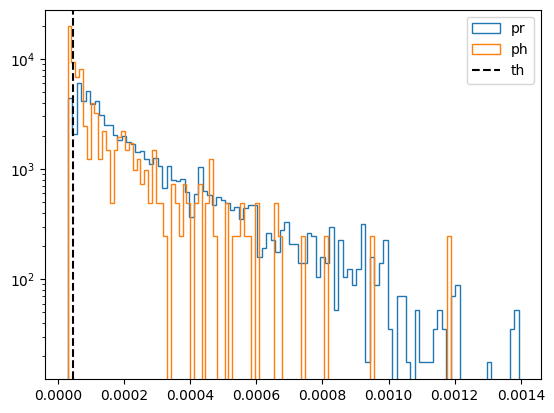

4182 351
284 94
284 94


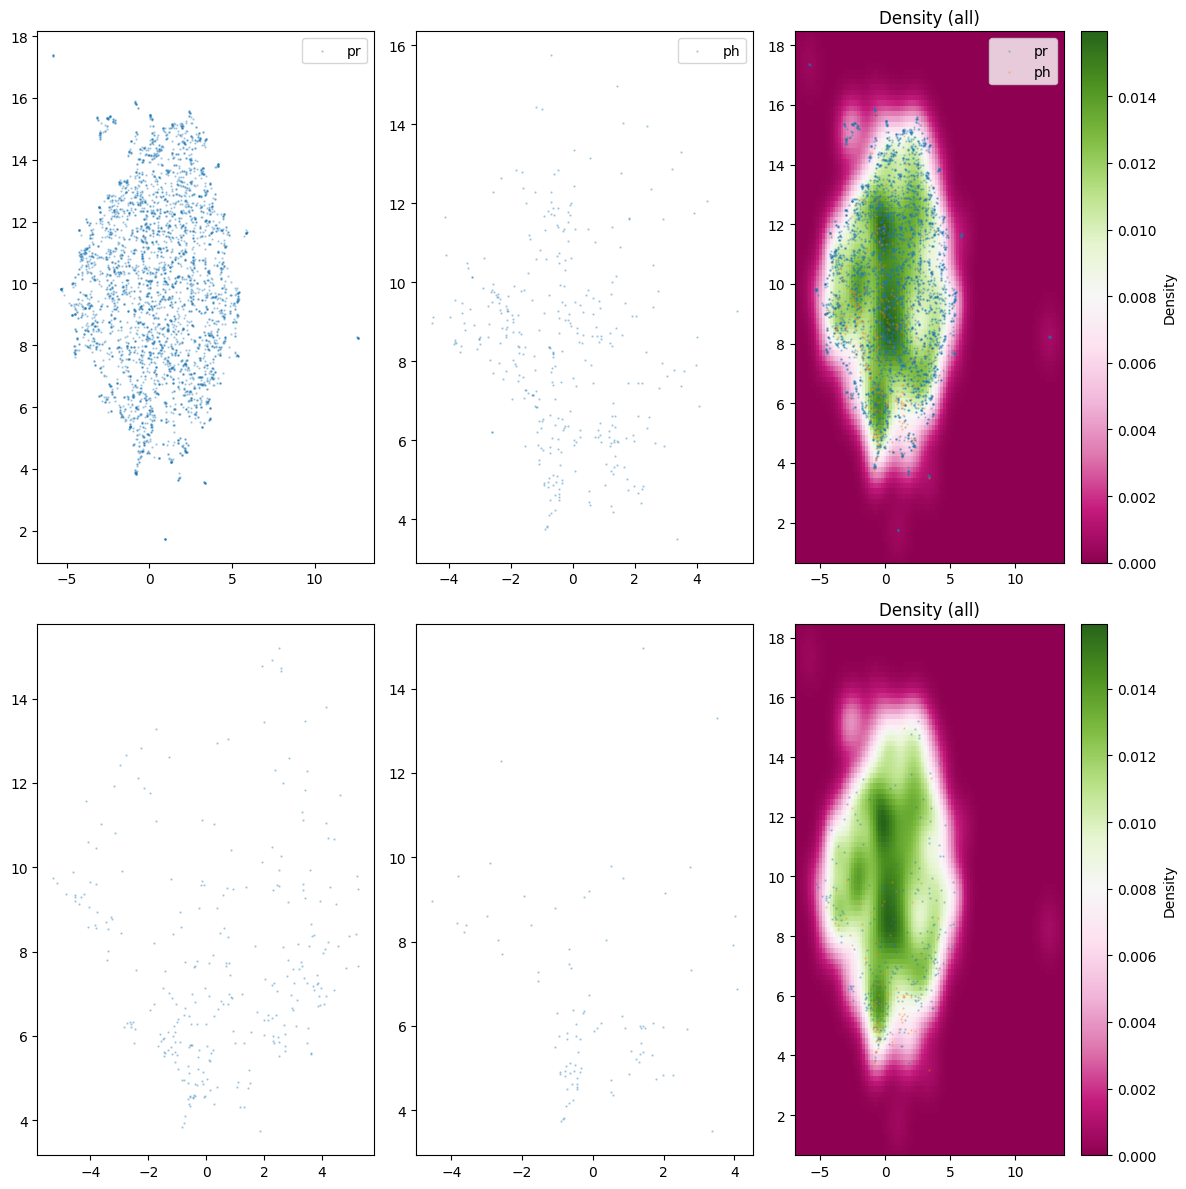

In [157]:
show_del_by_score(X_scaled[label_X == 0], X_scaled[label_X == 1], n_ph=1, density_ph=np.exp(scores_ph), density_pr=np.exp(scores_pr), th=np.exp(-10))

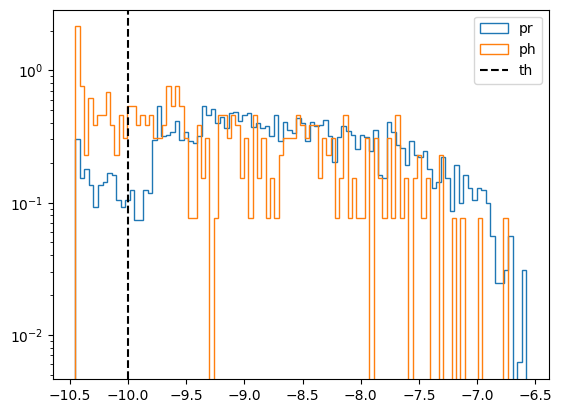

4182 351
284 94
284 94


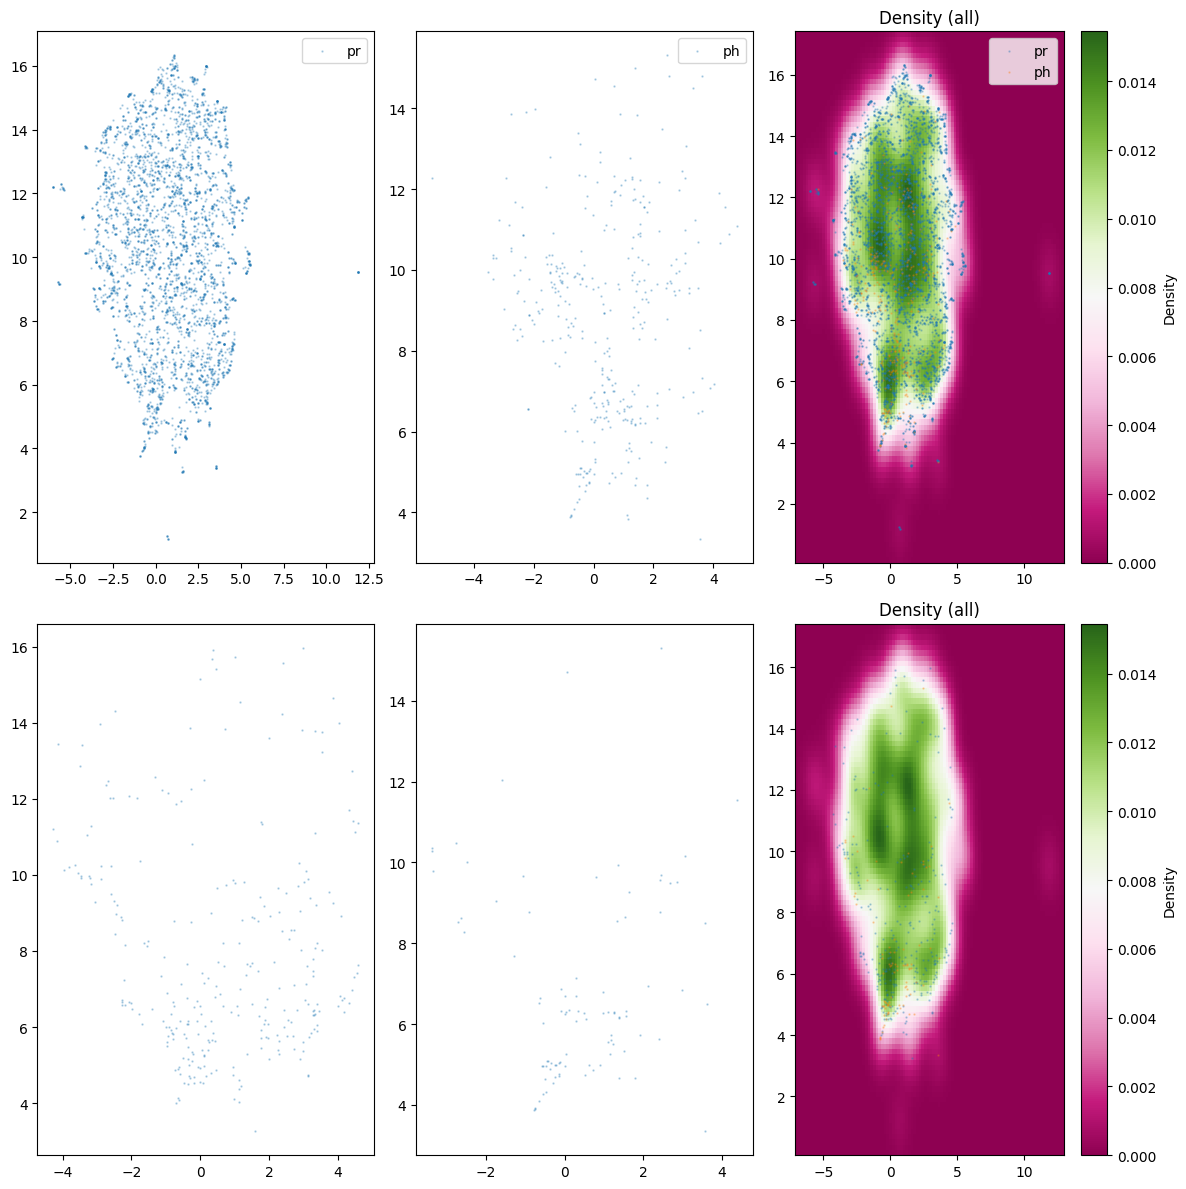

In [159]:
show_del_by_score(X_scaled[label_X == 0], X_scaled[label_X == 1], n_ph=1, density_ph=scores_ph, density_pr=scores_pr, th=-10)